# Playlist Analysis

An exploration of my music taste through the songs I've collected across my
Spotify playlists. Data was pulled from the Spotify Web API and analysed with
pandas, matplotlib, and seaborn.

**Contents**

1. Most common artists
2. Song-length distribution
3. Release-year distribution
4. Decade breakdown
5. Biggest playlists
6. Artists with the widest reach
7. Most-repeated songs
8. Adds over time
9. Playlist eclecticism
10. Average song length per playlist
11. Explicit vs. clean
12. Explicit ratio per playlist
13. Artist concentration per playlist
14. Library growth
15. Curation habits
16. Busiest months

*Note: Spotify's API no longer exposes genre or audio-feature data to new apps,
so this focuses on library structure and metadata rather than sonic qualities.*

## Setup

In [160]:
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

%matplotlib inline
sns.set_theme(style="whitegrid")
GREEN = "#1DB954"

# Fonts with glyph coverage for non-Latin (e.g. CJK) playlist names.
plt.rcParams["font.sans-serif"] = [
    "Arial Unicode MS", "PingFang SC", "Hiragino Sans GB", "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False
# Suppress warnings for glyphs (e.g. emoji) missing from the font.
warnings.filterwarnings("ignore", message="Glyph.*missing from font")

## Load data

In [ ]:
from pathlib import Path

# Resolve a project file path regardless of the current working directory.
def project_file(rel):
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / rel
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {rel} starting from {Path.cwd()}")

raw = pd.read_csv(project_file("data/api/playlist_tracks.csv"))

MY_NAME = "gene"   # playlist owner to keep
mine = raw[raw["playlist_owner"] == MY_NAME].copy()

# Playlists to exclude from the analysis.
BANNED_PLAYLISTS = [
    "background music and meme songs",
    "turi ip ip ip 😂🔥⁉️🚨😈😹🆒🔝",
    "every teardrop is a waterfall",
    "how to disappear completely",
    "john",
    "pink floyd",
    "smiths",
    "metaphorical music",
    "band i trust",
    "the paper kites/kings of convenience",
    "beats",
    "bad playlist",
    "best spotify mix party transitions",
    "joe"
]
mine = mine[~mine["playlist"].isin(BANNED_PLAYLISTS)].copy()

# Derived columns.
mine["added_at"] = pd.to_datetime(mine["added_at"], utc=True, errors="coerce")
mine["duration_min"] = mine["duration_ms"] / 60000
mine["release_year"] = pd.to_numeric(mine["release_date"].astype(str).str[:4],
                                     errors="coerce")

# Remove stub rows (local files / unavailable tracks with no metadata).
mine = mine[mine["track"].notna() & (mine["duration_ms"] > 0)].copy()

print(f"Playlist track entries (own playlists): {len(mine)}")
print(f"Unique songs:                           {mine['track_uri'].nunique()}")
print(f"Playlists:                              {mine['playlist'].nunique()}")
print(f"Unique artists:                         {mine['artist'].nunique()}")
mine.head()


Playlist track entries (own playlists): 8171
Unique songs:                           6762
Playlists:                              67
Unique artists:                         2882


,playlist,playlist_owner,position,added_at,track,artist,album,release_date,duration_ms,explicit,isrc,track_uri,duration_min,release_year
0,my favourite tracks of all time,gene,1,2026-07-19 07:29:57+00:00,All I Need,Radiohead,In Rainbows,2007-12-28,228746,False,GBSTK0700005,spotify:track:5Qv2Nby1xTr9pQyjkrc94J,3.812433,2007
1,my favourite tracks of all time,gene,2,2026-07-19 07:30:36+00:00,"Piano Concerto No. 3 in D Minor, Op. 30: I. Al...","Sergei Rachmaninoff, Yuja Wang, Los Angeles Ph...",Rachmaninoff: The Piano Concertos & Paganini R...,2023-09-01,983453,False,DEN962301491,spotify:track:1NgszQpmpnB792K6r9jz4k,16.390883,2023
2,my favourite tracks of all time,gene,3,2026-07-19 07:31:06+00:00,Seigfried,Frank Ocean,Blonde,2016-08-20,334570,False,QZ5C81600015,spotify:track:1BViPjTT585XAhkUUrkts0,5.576167,2016
3,my favourite tracks of all time,gene,4,2026-07-19 07:31:25+00:00,Moonlight on the River,Mac DeMarco,This Old Dog,2017-05-05,422613,False,QMMZN1701309,spotify:track:2fhOljbX79loRcdl47SFye,7.043550,2017
4,my favourite tracks of all time,gene,5,2026-07-19 07:32:07+00:00,Bags - Recorded At Electric Lady Studios,Clairo,Live at Electric Lady,2023-05-12,279413,False,USUG12302755,spotify:track:3ISKxnCGKc5B9zr9CTUB3v,4.656883,2023


## 1. Most common artists

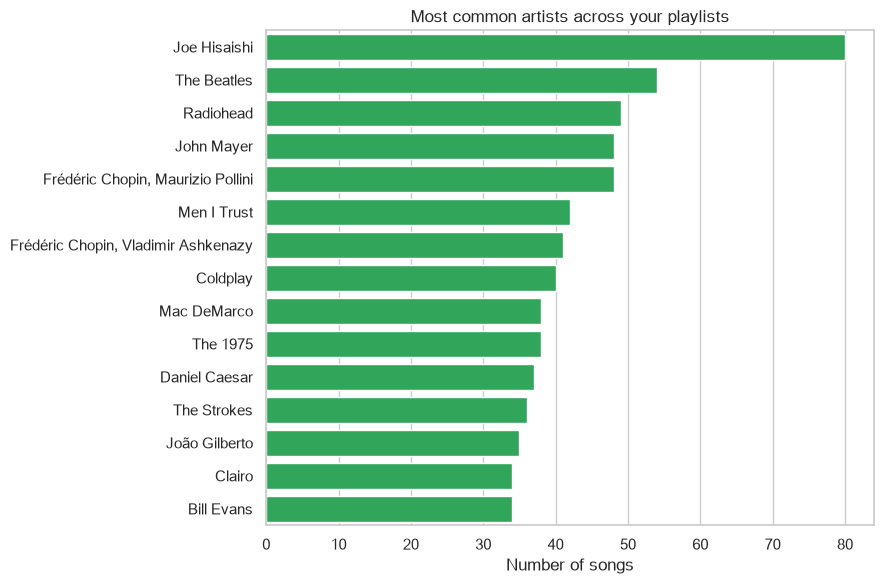

In [162]:
top_artists = mine["artist"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=top_artists.values, y=top_artists.index, color=GREEN, ax=ax)
ax.set_title("Most common artists across your playlists")
ax.set_xlabel("Number of songs")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 2. Song-length distribution

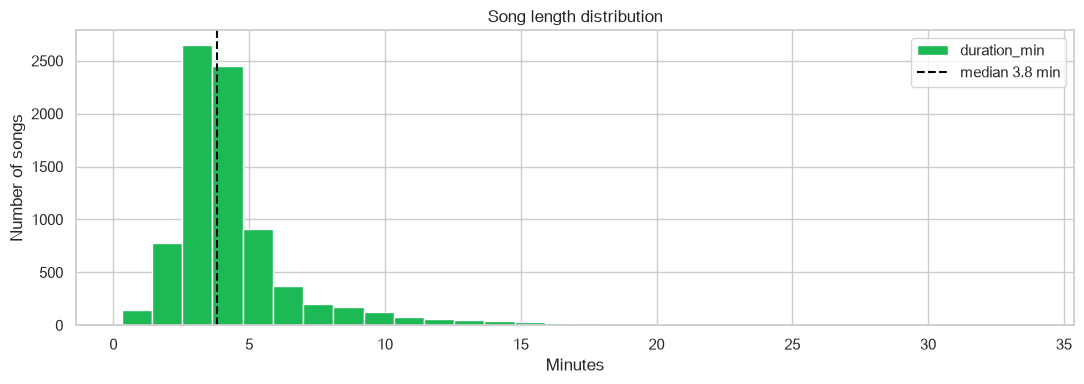

Longest:  Symphony No. 2 in C Minor "Resurrection": V. Finale. Im Tempo des Scherzos (33.7 min)
Shortest: Carnaval, Op. 9: 20. Pause (0.3 min)


In [163]:
fig, ax = plt.subplots(figsize=(11, 4))
mine["duration_min"].plot(kind="hist", bins=30, color=GREEN,
                             edgecolor="white", ax=ax)
ax.axvline(mine["duration_min"].median(), color="black",
           linestyle="--", label=f"median {mine['duration_min'].median():.1f} min")
ax.set_title("Song length distribution")
ax.set_xlabel("Minutes")
ax.set_ylabel("Number of songs")
ax.legend()
plt.tight_layout()
plt.show()

longest = mine.loc[mine["duration_min"].idxmax()]
shortest = mine.loc[mine["duration_min"].idxmin()]
print(f"Longest:  {longest['track']} ({longest['duration_min']:.1f} min)")
print(f"Shortest: {shortest['track']} ({shortest['duration_min']:.1f} min)")


## 3. Release-year distribution

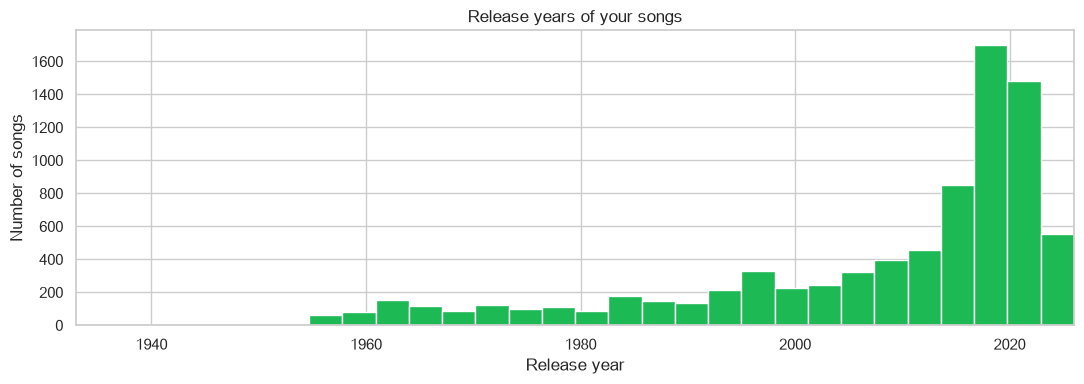

Oldest: 1933 — Tea for Two by Art Tatum
Newest: 2026 — Talk To You (ft. 54 Ultra) by ANOTR, 54 Ultra
Median: 2016


In [164]:
# Drop missing and invalid release years.
years = mine["release_year"].dropna()
years = years[years >= 1900]

lo, hi = int(years.min()), int(years.max())

fig, ax = plt.subplots(figsize=(11, 4))
# Limit the bars to the actual range of release years.
ax.hist(years, bins=30, range=(lo, hi), color=GREEN, edgecolor="white")
ax.set_xlim(lo, hi)                      # start the axis at the lowest year
ax.set_title("Release years of your songs")
ax.set_xlabel("Release year")
ax.set_ylabel("Number of songs")
plt.tight_layout()
plt.show()

# Oldest and newest songs by release year.
valid = mine[mine["release_year"] >= 1900]
oldest = valid.loc[valid["release_year"].idxmin()]
newest = valid.loc[valid["release_year"].idxmax()]

print(f"Oldest: {lo} — {oldest['track']} by {oldest['artist']}")
print(f"Newest: {hi} — {newest['track']} by {newest['artist']}")
print(f"Median: {int(years.median())}")

## 4. Decade breakdown

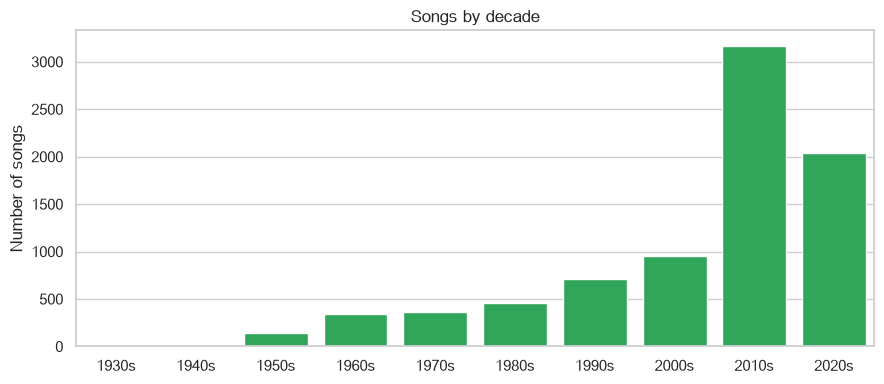

In [165]:
decade = (mine["release_year"] // 10 * 10).dropna().astype(int)
by_decade = decade.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=[f"{d}s" for d in by_decade.index], y=by_decade.values,
            color=GREEN, ax=ax)
ax.set_title("Songs by decade")
ax.set_xlabel("")
ax.set_ylabel("Number of songs")
plt.tight_layout()
plt.show()


## 5. Biggest playlists

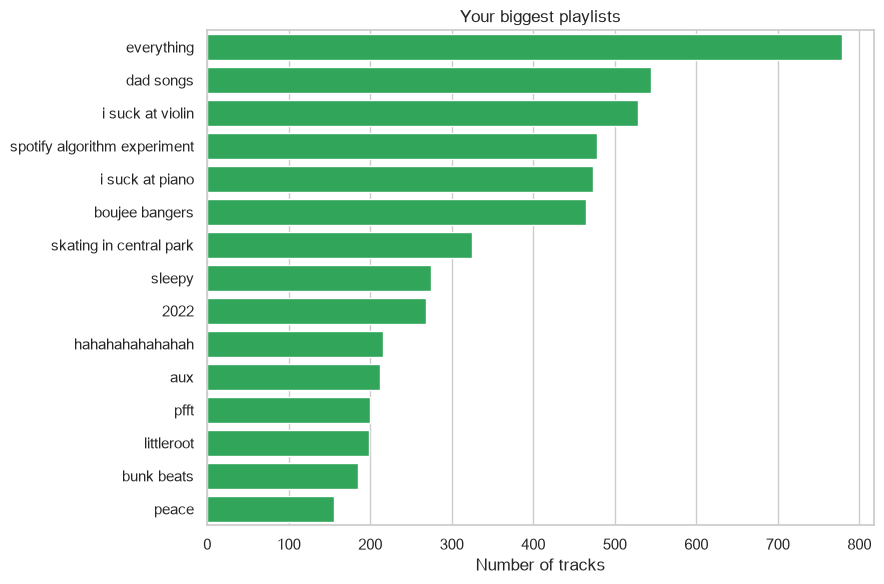

In [166]:
sizes = mine["playlist"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=sizes.values, y=sizes.index, color=GREEN, ax=ax)
ax.set_title("Your biggest playlists")
ax.set_xlabel("Number of tracks")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 6. Artists with the widest reach

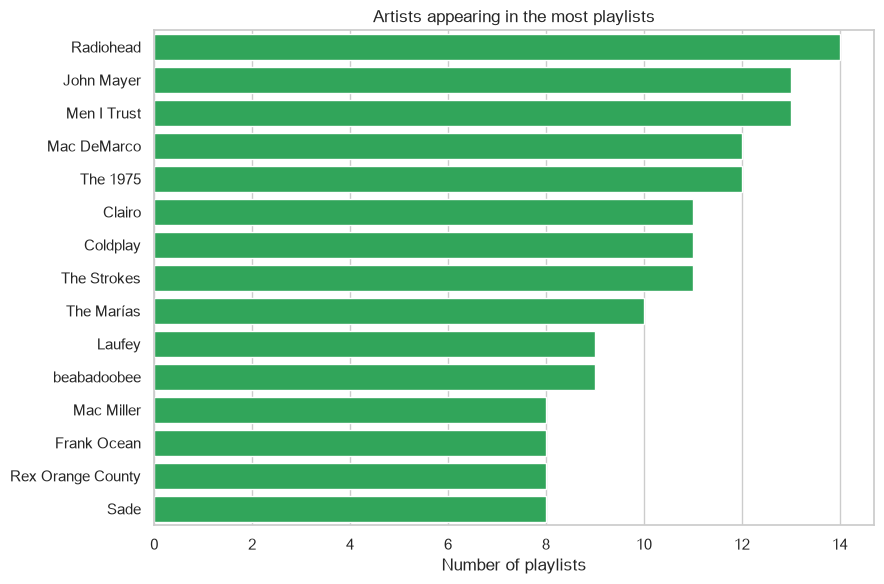

In [167]:
breadth = (mine.groupby("artist")["playlist"].nunique()
           .sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=breadth.values, y=breadth.index, color=GREEN, ax=ax)
ax.set_title("Artists appearing in the most playlists")
ax.set_xlabel("Number of playlists")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 7. Most-repeated songs

In [168]:
repeats = (mine.groupby(["track", "artist"])["playlist"].nunique()
           .sort_values(ascending=False))
repeats = repeats[repeats > 1].head(15)

if len(repeats):
    for (track, artist), n in repeats.items():
        print(f"  {n}x  {track} — {artist}")
else:
    print("No song appears in more than one of your playlists.")


  6x  Popo (How deep is our love?) — Yerin Baek
  6x  Tree Among Shrubs — Men I Trust
  6x  Show Me How — Men I Trust
  6x  Nude — Radiohead
  5x  Over the Moon — The Marías
  5x  Eleven Weeks — Vansire
  5x  Pierre — Men I Trust
  5x  Comedy — Gen Hoshino
  5x  When the Sun Hits — Slowdive
  4x  the perfect pair — beabadoobee
  4x  Simply — ADOY
  4x  Black Star — Radiohead
  4x  Another One — Mac DeMarco
  4x  Is there free breakfast here? — Hotel Ugly
  4x  The Sixth Station — Joe Hisaishi


## 8. Adds over time

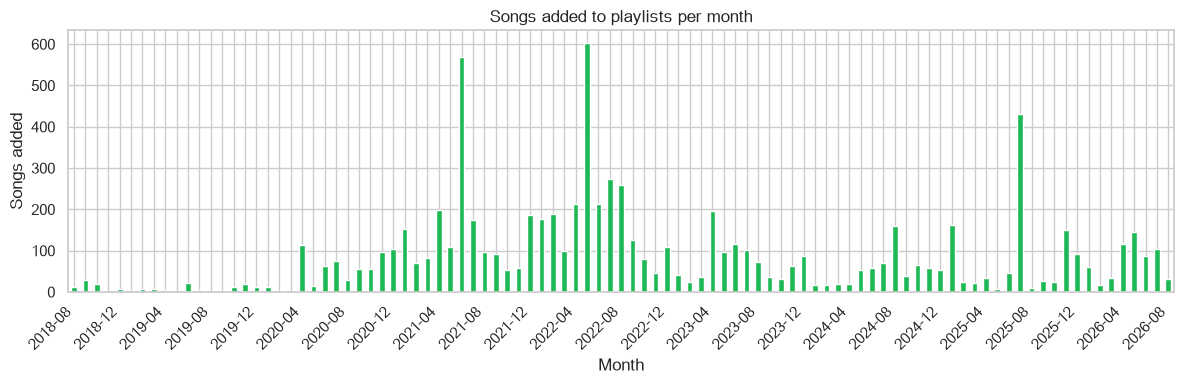

In [169]:
monthly = mine.dropna(subset=["added_at"]).copy()
monthly["month"] = monthly["added_at"].dt.strftime("%Y-%m")
counts = monthly.groupby("month").size()

if len(counts):
    all_months = pd.period_range(start=counts.index.min(),
                                 end=counts.index.max(), freq="M").astype(str)
    counts = counts.reindex(all_months, fill_value=0)

    fig, ax = plt.subplots(figsize=(12, 4))
    counts.plot(kind="bar", ax=ax, color=GREEN)
    ax.set_title("Songs added to playlists per month")
    ax.set_xlabel("Month")
    ax.set_ylabel("Songs added")
    # Thin x-axis labels when there are many months.
    step = max(1, len(counts) // 24)
    for i, lbl in enumerate(ax.get_xticklabels()):
        lbl.set_visible(i % step == 0)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No 'added_at' dates available.")


## 9. Playlist eclecticism

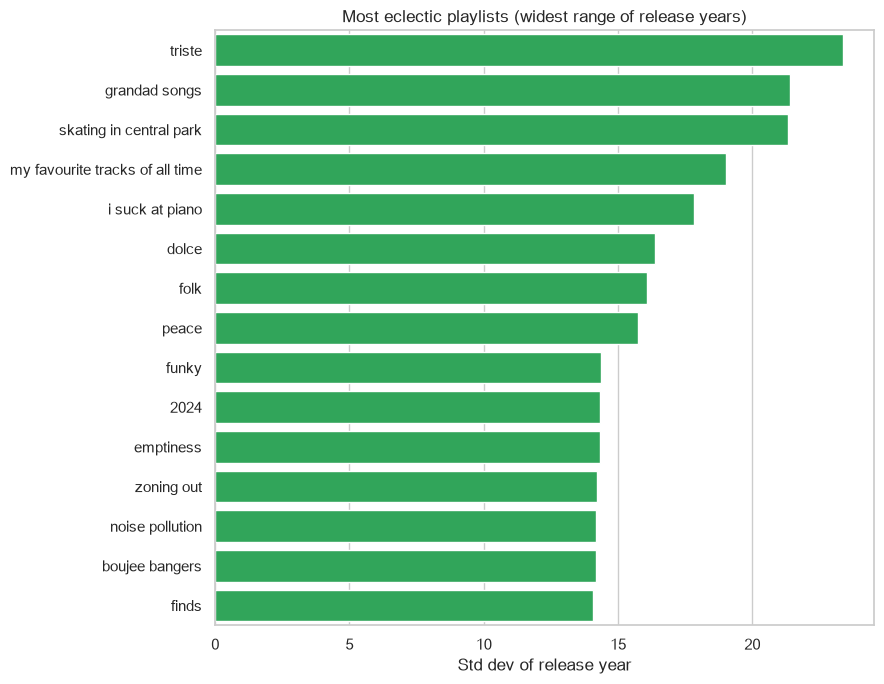

In [170]:
counts = mine.groupby("playlist")["release_year"].count()
eligible = counts[counts >= 5].index
spread = (mine[mine["playlist"].isin(eligible)]
          .groupby("playlist")["release_year"].std()
          .sort_values(ascending=False))

top = spread.head(15)
fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(x=top.values, y=top.index, color=GREEN, ax=ax)
ax.set_title("Most eclectic playlists (widest range of release years)")
ax.set_xlabel("Std dev of release year")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 10. Average song length per playlist

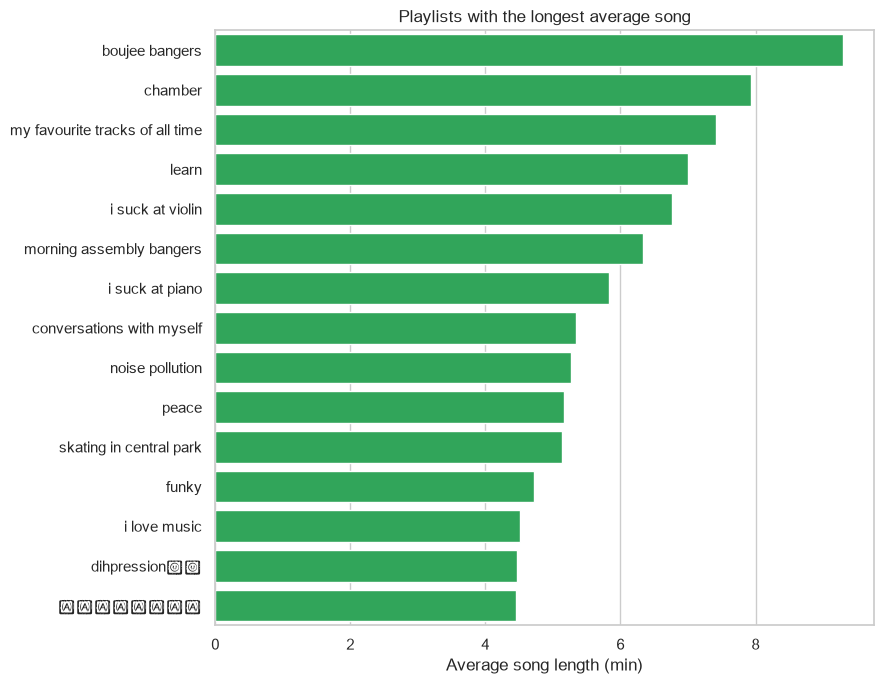

In [171]:
avg_len = (mine.groupby("playlist")["duration_min"].mean()
           .sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(x=avg_len.values, y=avg_len.index, color=GREEN, ax=ax)
ax.set_title("Playlists with the longest average song")
ax.set_xlabel("Average song length (min)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 11. Explicit vs. clean

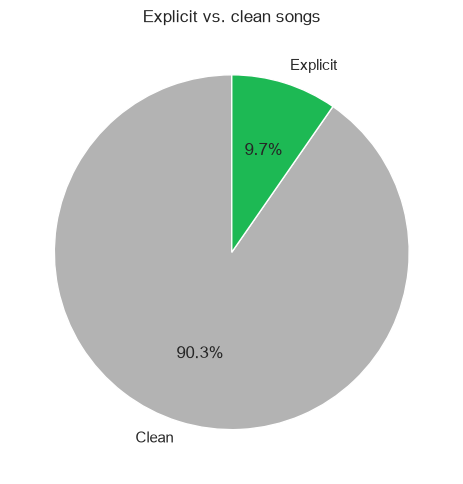

In [172]:
songs = mine.drop_duplicates("track_uri")
counts = songs["explicit"].value_counts().reindex([False, True], fill_value=0)

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(counts.values, labels=["Clean", "Explicit"], autopct="%1.1f%%",
       colors=["#b3b3b3", GREEN], startangle=90)
ax.set_title("Explicit vs. clean songs")
plt.tight_layout()
plt.show()

## 12. Explicit ratio per playlist

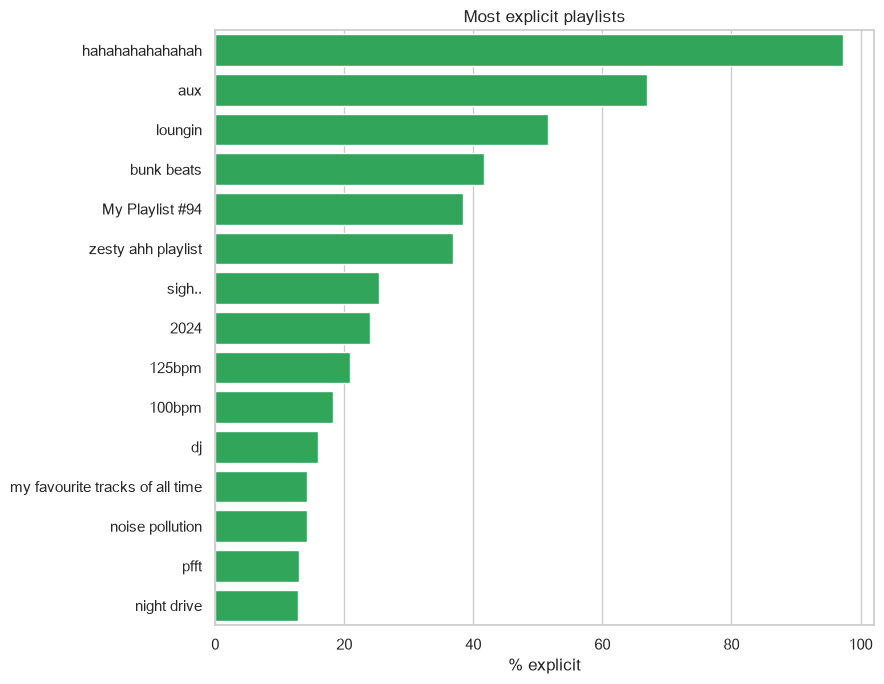

In [173]:
expl = (mine.groupby("playlist")["explicit"].mean().mul(100)
        .sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(x=expl.values, y=expl.index, color=GREEN, ax=ax)
ax.set_title("Most explicit playlists")
ax.set_xlabel("% explicit")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 13. Artist concentration per playlist

,tracks,artists,diversity
playlist,,,
joe,67,6,0.089552
lullabies,33,6,0.181818
chamber,101,22,0.217822
i suck at piano,473,106,0.224101
triste,76,18,0.236842
boujee bangers,465,122,0.262366
conversations with myself,15,4,0.266667
uk,29,8,0.275862
dihpression🥀🥀,57,16,0.280702


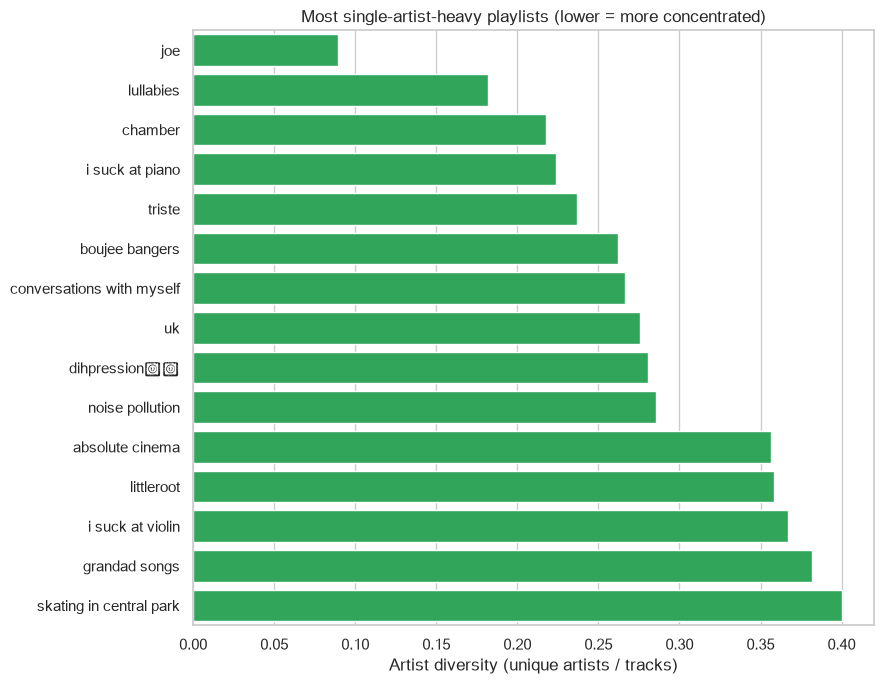

In [174]:
g = (mine.groupby("playlist")
     .agg(tracks=("track_uri", "nunique"), artists=("artist", "nunique")))
g = g[g["tracks"] >= 5]
g["diversity"] = g["artists"] / g["tracks"]
most_concentrated = g.sort_values("diversity").head(15)

display(most_concentrated)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(x=most_concentrated["diversity"], y=most_concentrated.index,
            color=GREEN, ax=ax)
ax.set_title("Most single-artist-heavy playlists (lower = more concentrated)")
ax.set_xlabel("Artist diversity (unique artists / tracks)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 14. Library growth over time

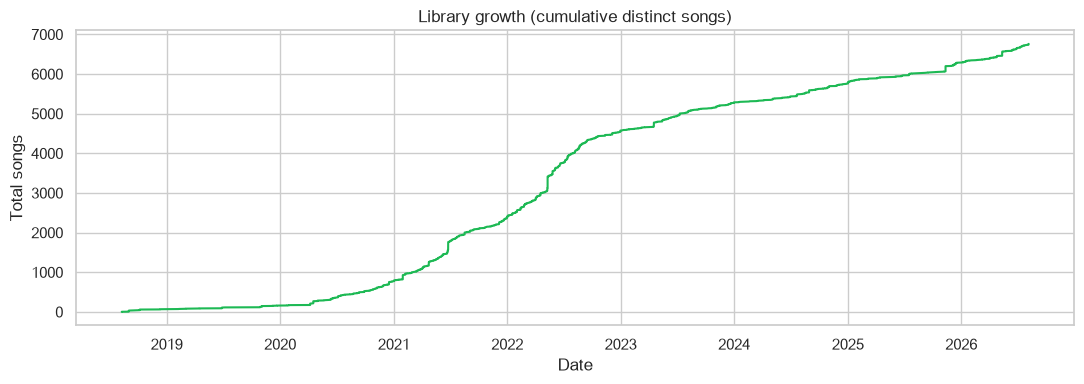

In [175]:
first_added = (mine.dropna(subset=["added_at"])
               .groupby("track_uri")["added_at"].min()
               .sort_values())
growth = pd.Series(range(1, len(first_added) + 1), index=first_added.values)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(growth.index, growth.values, color=GREEN)
ax.set_title("Library growth (cumulative distinct songs)")
ax.set_xlabel("Date")
ax.set_ylabel("Total songs")
plt.tight_layout()
plt.show()

## 15. Curation habits

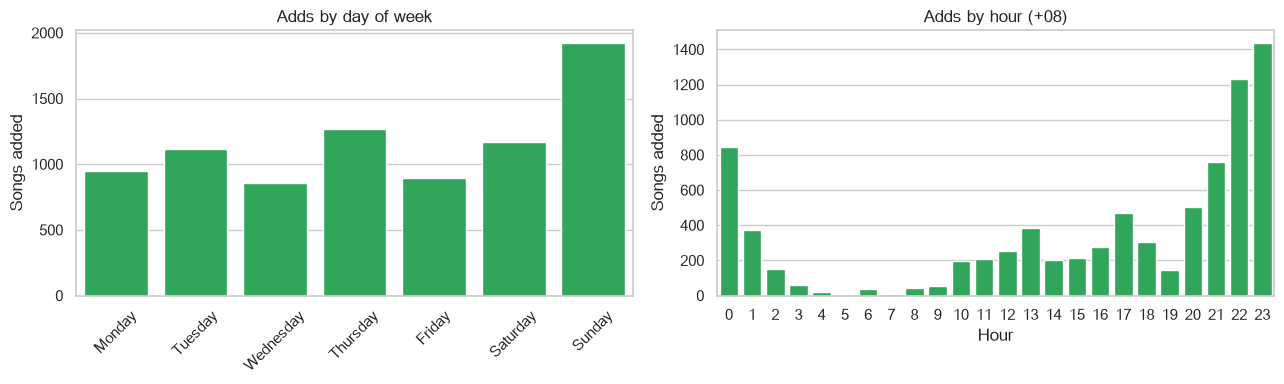

In [176]:
from datetime import datetime

# Local timezone from the system clock.
local_tz = datetime.now().astimezone().tzinfo

added = mine.dropna(subset=["added_at"]).copy()
local_dt = added["added_at"].dt.tz_convert(local_tz)   # UTC -> local

order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday",
         "Saturday", "Sunday"]
dow = local_dt.dt.day_name().value_counts().reindex(order, fill_value=0)
hour = local_dt.dt.hour.value_counts().reindex(range(24), fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(x=dow.index, y=dow.values, color=GREEN, ax=axes[0])
axes[0].set_title("Adds by day of week")
axes[0].set_xlabel("")
axes[0].set_ylabel("Songs added")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(x=hour.index, y=hour.values, color=GREEN, ax=axes[1])
axes[1].set_title(f"Adds by hour ({local_tz})")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Songs added")

plt.tight_layout()
plt.show()

## 16. Busiest months

,songs_added
month,
2022-05,603
2021-06,569
2025-07,430
2022-07,273
2022-08,259
2022-04,214
2022-06,213
2021-04,199
2023-04,195


Busiest month: 2022-05 with 603 adds


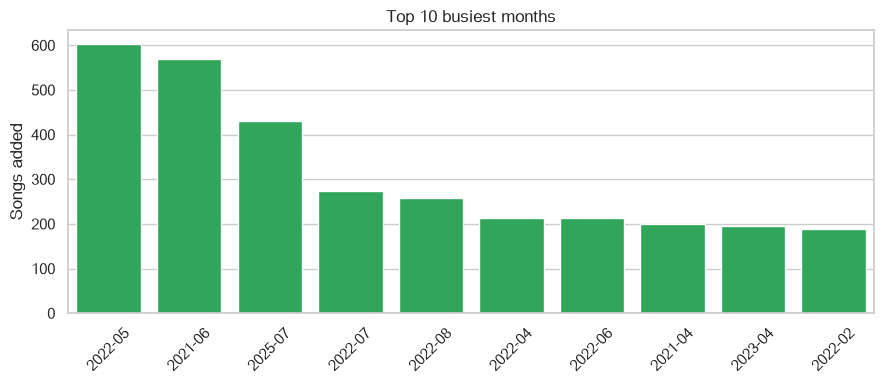

In [177]:
m = mine.dropna(subset=["added_at"]).copy()
m["month"] = m["added_at"].dt.strftime("%Y-%m")
busiest = m.groupby("month").size().sort_values(ascending=False).head(10)

display(busiest.to_frame("songs_added"))
print(f"Busiest month: {busiest.idxmax()} with {busiest.max()} adds")

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=busiest.index, y=busiest.values, color=GREEN, ax=ax)
ax.set_title("Top 10 busiest months")
ax.set_xlabel("")
ax.set_ylabel("Songs added")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## Notes

This analysis covers songs I've saved to playlists, not play counts — the
Spotify API doesn't expose full listening history. Times in the curation-habits
section are shown in local time.